# True Market Price — Deriving Expected Value from Polymarket Binary Options

**Research Question:** Can we reconstruct a continuous price distribution from discrete Polymarket binary buckets and identify α (alpha) vs. the Futures market?

## Methodology

| Step | Operation | Tool |
|---|---|---|
| 1 | Convert binary `yes_price` → CDF points | Convention: up→`1−p`, down→`p` |
| 2 | Smooth CDF | `PchipInterpolator` (monotone cubic spline) |
| 3 | Tail extension | Log-Normal fit via `scipy.stats.lognorm` |
| 4 | Derive PDF | `np.gradient` of smooth CDF |
| 5 | Expected Value | `∫ x·f(x) dx` via `np.trapz` |
| 6 | Alpha signal | Basis Gap Z-score vs NYMEX Futures |

> **Note on option type:** Polymarket "Will CL exceed $K by end-March?" markets are binary *touch* options, not European vanillas. Near expiry, touch probability ≈ terminal probability — a reasonable approximation for the final week of the contract.

In [2]:

# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
import matplotlib.gridspec as gridspec
from matplotlib.lines   import Line2D
from matplotlib.patches import Patch

from scipy.interpolate import PchipInterpolator
from scipy.stats       import lognorm, norm

# ── Colour palette ────────────────────────────────────────────────────────────
P = {
    "pm_obs":    "#2563EB",   # observed CDF points
    "cdf_fit":   "#1D4ED8",   # smooth CDF line
    "lognorm":   "#7C3AED",   # log-normal reference
    "pdf_fill":  "#818CF8",   # PDF area
    "ev":        "#DC2626",   # Expected Value marker
    "mode":      "#EA580C",   # Mode marker
    "futures":   "#16A34A",   # NYMEX futures
    "buy":       "#16A34A",   # positive basis
    "sell":      "#DC2626",   # negative basis
    "zscore":    "#6B7280",   # z-score line
    "ci":        "#C7D2FE",   # 90% CI band
}

plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "font.family":       "DejaVu Sans",
})
plt.rcParams["grid.alpha"] = 0.28

ROOT = Path("../data/raw")
print("✓  setup complete")


✓  setup complete


In [3]:

# ── Load Polymarket raw prices ────────────────────────────────────────────────
pm_raw = pd.read_csv(ROOT / "polymarket/crude_oil_prices.csv",
                     parse_dates=["timestamp"])
pm_raw["timestamp"]  = pd.to_datetime(pm_raw["timestamp"], utc=True)
pm_raw["strike_val"] = pm_raw["strike"].str.replace("$", "", regex=False).astype(int)

# ── Load NYMEX front-month futures (30-min bars → hourly close) ───────────────
nymex    = pd.read_csv(ROOT / "nymex/CL_F_30m.csv", parse_dates=["timestamp"])
nymex["timestamp"] = pd.to_datetime(nymex["timestamp"], utc=True)
nymex    = nymex.set_index("timestamp").sort_index()
nymex_1h = nymex["close"].resample("1h").last().ffill()

# ── Coverage summary ──────────────────────────────────────────────────────────
strikes = sorted(pm_raw["strike_val"].unique())
cov = (pm_raw.groupby(["strike_val", "direction"])["timestamp"]
       .agg(["min", "max", "count"])
       .reset_index()
       .rename(columns={"min": "from", "max": "to", "count": "n_obs"}))
cov["from"] = cov["from"].dt.date
cov["to"]   = cov["to"].dt.date

print(f"Polymarket  │  {len(strikes)} strikes: {strikes}")
print(f"            │  Period: {pm_raw['timestamp'].min().date()} → {pm_raw['timestamp'].max().date()}")
print(f"NYMEX 1 h   │  {len(nymex_1h)} rows  "
      f"${nymex_1h.dropna().min():.1f} – ${nymex_1h.dropna().max():.1f}\n")
print(cov.to_string(index=False))


Polymarket  │  21 strikes: [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 120, 130, 140, 150, 180, 200]
            │  Period: 2026-02-28 → 2026-03-28
NYMEX 1 h   │  622 rows  $69.7 – $115.9

 strike_val direction       from         to  n_obs
         40      down 2026-02-28 2026-03-28   3995
         45      down 2026-02-28 2026-03-28   3912
         50      down 2026-02-28 2026-03-28   3943
         55      down 2026-02-28 2026-03-28   3985
         60      down 2026-02-28 2026-03-28   3908
         65      down 2026-02-28 2026-03-28   3966
         70      down 2026-03-09 2026-03-28   2702
         70        up 2026-02-28 2026-03-03    354
         75      down 2026-03-09 2026-03-28   2711
         75        up 2026-02-28 2026-03-06    769
         80      down 2026-03-09 2026-03-28   2709
         80        up 2026-02-28 2026-03-06    799
         85      down 2026-03-09 2026-03-28   1497
         90      down 2026-03-19 2026-03-24    652
         90        up 2026

---
## 1 · CDF Construction

**Convention** — both "up" and "down" Polymarket markets encode $F(K) = P(S \leq K)$:

$$F(K) = \begin{cases} 1 - p_{\text{yes}} & \text{if up market at strike } K \\ p_{\text{yes}} & \text{if down market at strike } K \end{cases}$$

**Smoothing** — raw market prices are noisy; we:
1. Enforce weak monotonicity (`np.maximum.accumulate`)
2. Fit a **PchipInterpolator** (monotone Hermite spline) through all observed CDF points — guarantees a non-negative derivative (PDF)
3. Extrapolate beyond the observed strike range using a **Log-Normal** fitted to the bulk of the distribution via probit regression on $\ln K$

In [14]:

def build_cdf_snapshot(pm_raw: pd.DataFrame, t: pd.Timestamp) -> pd.DataFrame:
    """
    Build discrete CDF points { K → F(K) = P(S ≤ K) } from all Polymarket
    binary options available at or before timestamp t.

    Up   market: yes_price = P(S > K)  ⟹  F(K) = 1 − yes_price
    Down market: yes_price = P(S < K)  ⟹  F(K) = yes_price

    When both an up and a down market exist at the same strike, their implied
    CDF values are averaged (reduces microstructure noise, exploits no-arb
    constraint F_up + F_down ≈ 1 but both near 0.5 at the money).
    """
    past = pm_raw[pm_raw["timestamp"] <= t]
    if len(past) < 2:
        return pd.DataFrame(columns=["strike", "cdf_value"])

    # Latest observation per (strike, direction) ≤ t
    latest = (past.sort_values("timestamp")
                  .groupby(["strike_val", "direction"], as_index=False)
                  .last()[["strike_val", "direction", "price"]])

    rows = []
    for _, row in latest.iterrows():
        p     = float(row["price"])
        cdf_v = (1.0 - p) if row["direction"] == "up" else p
        rows.append({"strike": float(row["strike_val"]), "cdf_value": cdf_v})

    df = (pd.DataFrame(rows)
            .groupby("strike", as_index=False)["cdf_value"].mean()
            .sort_values("strike")
            .reset_index(drop=True))

    # Clip to safe probability range (avoids probit divergence at 0/1)
    df["cdf_value"] = df["cdf_value"].clip(1e-4, 1 - 1e-4)
    # Enforce weak monotonicity — market noise can create tiny inversions
    df["cdf_value"] = np.maximum.accumulate(df["cdf_value"].values)

    return df


In [15]:

def fit_smooth_cdf(df_cdf: pd.DataFrame,
                   x_min:  float = 35.0,
                   x_max:  float = 230.0,
                   n_grid: int   = 1_000) -> dict:
    """
    Smooth a discrete Polymarket CDF using PCHIP + Log-Normal tails.

    Pipeline
    ────────
    1. Probit-regression on ln(K) to fit log-normal (μ, σ) from bulk points
    2. Anchor boundary points:  F( 0.4 · K_min ) = 0,  F( 1.6 · K_max ) = 1
    3. PchipInterpolator within [anchored_min, anchored_max]
    4. Log-normal fill for x outside PCHIP domain (NaN regions)
    5. np.gradient → PDF  (non-negative by construction after clip)
    6. Trapezoid normalisation → ∫ f dx = 1

    Returns
    ───────
    dict with keys: x_grid, cdf, pdf, ev, mode, ci_90,
                    lognorm_params (μ, σ), cdf_lognorm, K_obs, F_obs
    """
    K     = df_cdf["strike"].values.astype(float)
    F_obs = df_cdf["cdf_value"].values.astype(float)

    # ── 1. Log-normal fit via probit regression on ln K ───────────────────────
    valid = (F_obs > 0.02) & (F_obs < 0.98)
    if valid.sum() >= 3:
        z_vals  = norm.ppf(F_obs[valid])
        ln_K    = np.log(K[valid])
        coeffs  = np.polyfit(ln_K, z_vals, 1)           # z = a·ln K + b
        sigma_ln = max(1.0 / coeffs[0], 0.01)
        mu_ln    = -coeffs[1] * sigma_ln
    else:
        mu_ln, sigma_ln = np.log(80.0), 0.25            # fallback prior

    # ── 2. Boundary anchors ───────────────────────────────────────────────────
    K_lo  = max(1.0, K[0]  * 0.40)
    K_hi  = K[-1] * 1.60
    K_ext = np.concatenate([[K_lo], K, [K_hi]])
    F_ext = np.concatenate([[0.0],  F_obs, [1.0]])

    # ── 3. PCHIP within anchored range ────────────────────────────────────────
    pchip = PchipInterpolator(K_ext, F_ext, extrapolate=False)

    x_grid    = np.linspace(x_min, x_max, n_grid)
    cdf_pchip = pchip(x_grid)          # NaN outside [K_lo, K_hi]

    # ── 4. Log-normal tail fill ───────────────────────────────────────────────
    cdf_ln = lognorm.cdf(x_grid, s=sigma_ln, scale=np.exp(mu_ln))
    cdf_smooth = np.where(np.isnan(cdf_pchip), cdf_ln, cdf_pchip)
    cdf_smooth = np.clip(np.maximum.accumulate(cdf_smooth), 0.0, 1.0)

    # ── 5. PDF via numerical gradient, clip negatives ─────────────────────────
    dx         = x_grid[1] - x_grid[0]
    pdf_smooth = np.maximum(np.gradient(cdf_smooth, dx), 0.0)

    # ── 6. Normalise PDF ──────────────────────────────────────────────────────
    area = np.trapz(pdf_smooth, x_grid)
    if area > 1e-10:
        pdf_smooth /= area

    # ── Summary statistics ────────────────────────────────────────────────────
    ev   = float(np.trapz(x_grid * pdf_smooth, x_grid))
    mode = float(x_grid[np.argmax(pdf_smooth)])

    # 90% credible interval from CDF
    cumsum = np.cumsum(pdf_smooth) * dx
    ci_lo  = float(x_grid[np.searchsorted(cumsum, 0.05)])
    ci_hi  = float(x_grid[np.searchsorted(cumsum, 0.95)])

    return {
        "x_grid":         x_grid,
        "cdf":            cdf_smooth,
        "pdf":            pdf_smooth,
        "ev":             ev,
        "mode":           mode,
        "ci_90":          (ci_lo, ci_hi),
        "lognorm_params": (mu_ln, sigma_ln),
        "cdf_lognorm":    cdf_ln,
        "K_obs":          K,
        "F_obs":          F_obs,
    }


---
## 2 · Expected Value & Alpha Signal

$$\text{EV} = E[X] = \int_{x_{\min}}^{x_{\max}} x \cdot f(x)\, dx$$

The **Basis Gap** is the spread between the crowd-implied expected price and the quoted futures price:

$$\text{BasisGap}_t = \text{EV}_t - F_t^{\text{futures}}$$

A persistent non-zero gap suggests the prediction market crowd and futures market traders hold different probability assessments — a potential edge.

**Z-Score Signal** standardises the basis gap over a rolling history window:

$$Z_t = \frac{\text{BasisGap}_t - \mu_{\text{basis}}}{\sigma_{\text{basis}}}$$

| Z-score | Signal | Interpretation |
|---|---|---|
| $Z > +1$ | **BUY** | PM crowd prices higher than futures → futures may catch up |
| $Z < -1$ | **SELL** | PM crowd prices lower than futures → futures may fall |
| $\|Z\| \leq 1$ | **HOLD** | No statistically significant divergence |

In [7]:

def alpha_signal(ev, futures_price, gap_history=None, z_threshold=1.0):
    """
    Compute the Basis Gap and derive a directional trading signal.

    Parameters
    ──────────
    ev            : Polymarket implied Expected Value (the 'True Price')
    futures_price : Current NYMEX CL front-month futures price
    gap_history   : Rolling list of past basis-gap values (used for Z-score)
    z_threshold   : |Z| threshold to trigger BUY / SELL (default 1.0σ)

    Returns
    ───────
    dict with keys: basis_gap, z_score, signal (+1 BUY / -1 SELL / 0 HOLD)
    """
    basis_gap = ev - futures_price

    if gap_history and len(gap_history) >= 5:
        arr     = np.array(gap_history[-500:], dtype=float)
        mu_g    = arr.mean()
        sig_g   = arr.std(ddof=1)
        z_score = (basis_gap - mu_g) / sig_g if sig_g > 1e-8 else 0.0
    else:
        z_score = 0.0

    if   z_score >  z_threshold: signal =  1    # BUY
    elif z_score < -z_threshold: signal = -1    # SELL
    else:                        signal =  0    # HOLD

    return {"basis_gap": basis_gap, "z_score": z_score, "signal": signal}


In [8]:

# ── Demo Snapshot ─────────────────────────────────────────────────────────────
# Use Mar-20 16:00 UTC — well inside the NYMEX window (Mar 1–27)
# and after most "up" markets in the $70–80 range have resolved,
# giving us a rich set of CDF points across the full $40–200 range.
T_DEMO = pd.Timestamp("2026-03-20 16:00:00", tz="UTC")

snap    = build_cdf_snapshot(pm_raw, T_DEMO)
result  = fit_smooth_cdf(snap)
futures = float(nymex_1h.asof(T_DEMO))
signal  = alpha_signal(result["ev"], futures)

mu_ln, sig_ln = result["lognorm_params"]
lo, hi        = result["ci_90"]

# ── Print report ──────────────────────────────────────────────────────────────
print(f"  Snapshot : {T_DEMO.strftime('%d %b %Y  %H:%M')} UTC\n")
print(f"  {'Strike':>8}   {'F(K) obs':>10}   {'F(K) fit':>10}   {'Source'}")
print(f"  {'──────':>8}   {'────────':>10}   {'────────':>10}   {'──────'}")
for _, r in snap.iterrows():
    k    = r["strike"]
    idx  = int(np.searchsorted(result["x_grid"], k))
    ffit = result["cdf"][min(idx, len(result["cdf"]) - 1)]
    dir_mask = (pm_raw["strike_val"] == int(k))
    dirs     = pm_raw.loc[dir_mask, "direction"].unique()
    src      = " + ".join(sorted(dirs))
    print(f"  ${k:>6.0f}       {r['cdf_value']:>9.4f}    {ffit:>9.4f}   {src}")

print(f"\n  {'─'*52}")
print(f"  Log-Normal fit        μ={mu_ln:.4f}  σ={sig_ln:.4f}")
print(f"  {'─'*52}")
print(f"  Model-implied EV  (E[X])   :  ${result['ev']:>8.3f}")
print(f"  Mode (highest-density)     :  ${result['mode']:>8.3f}")
print(f"  NYMEX Futures              :  ${futures:>8.3f}")
print(f"  Basis Gap  (EV − Futures)  :  ${signal['basis_gap']:>+8.3f}")
print(f"  90% Credible Interval      :  [${lo:.1f},  ${hi:.1f}]")
print(f"  Z-score                    :  {signal['z_score']:>+8.3f}  (no history yet)")
print(f"  {'─'*52}")
print(f"  Signal  →  {'BUY ▲' if signal['signal']==1 else 'SELL ▼' if signal['signal']==-1 else 'HOLD ─'}")


  Snapshot : 20 Mar 2026  16:00 UTC

    Strike     F(K) obs     F(K) fit   Source
    ──────     ────────     ────────   ──────
  $    40          0.0025       0.0025   down
  $    45          0.0030       0.0030   down
  $    50          0.0065       0.0065   down
  $    55          0.0065       0.0065   down
  $    60          0.0115       0.0115   down
  $    65          0.0120       0.0120   down
  $    70          0.0137       0.0138   down + up
  $    75          0.0215       0.0215   down + up
  $    80          0.0327       0.0333   down + up
  $    85          0.1900       0.1904   down
  $    90          0.1962       0.1962   down + up
  $    95          0.1962       0.1964   up
  $   100          0.3120       0.3120   up
  $   105          0.5445       0.5475   up
  $   110          0.7210       0.7234   up
  $   120          0.8150       0.8161   up
  $   130          0.9250       0.9253   up
  $   140          0.9575       0.9575   up
  $   150          0.9760       0.976

---
## 3 · Visualisations

### Plot 1 — Discrete Polymarket Points vs Smooth Interpolated CDF

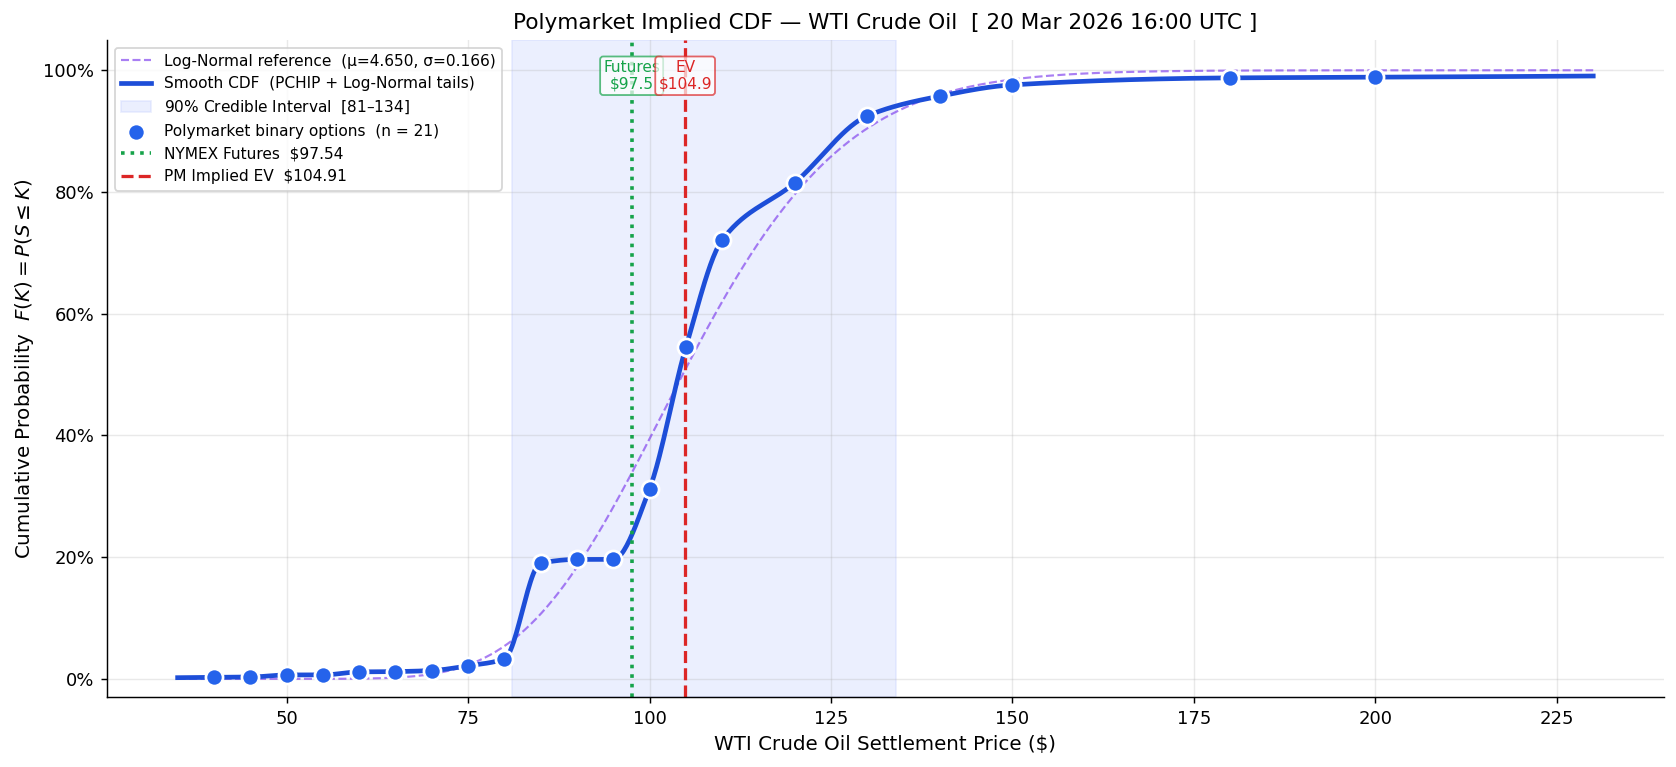

Saved → outputs/true_price_cdf.png


In [9]:

# ── Plot 1 · Discrete PM Points vs Smooth CDF ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

x, cdf_s, cdf_ln = result["x_grid"], result["cdf"], result["cdf_lognorm"]
lo, hi = result["ci_90"]

# Log-normal reference  (dashed background)
ax.plot(x, cdf_ln,
        color=P["lognorm"], lw=1.2, ls="--", alpha=0.65,
        label=f"Log-Normal reference  (μ={mu_ln:.3f}, σ={sig_ln:.3f})")

# Blended PCHIP + tail CDF
ax.plot(x, cdf_s,
        color=P["cdf_fit"], lw=2.6,
        label="Smooth CDF  (PCHIP + Log-Normal tails)")

# 90% CI band
ax.axvspan(lo, hi, color=P["ci"], alpha=0.35, zorder=0,
           label=f"90% Credible Interval  [${lo:.0f} – ${hi:.0f}]")

# Observed Polymarket CDF dots
ax.scatter(result["K_obs"], result["F_obs"],
           s=90, zorder=6, color=P["pm_obs"],
           edgecolors="white", linewidth=1.5,
           label=f"Polymarket binary options  (n = {len(result['K_obs'])})")

# NYMEX vertical
ax.axvline(futures, color=P["futures"], lw=2.0, ls=":",
           label=f"NYMEX Futures  ${futures:.2f}")

# EV vertical
ax.axvline(result["ev"], color=P["ev"], lw=1.8, ls="--",
           label=f"PM Implied EV  ${result['ev']:.2f}")

# Annotations at the top of each vertical line
for x_pos, label, color in [
    (futures,       f"Futures\n${futures:.1f}",    P["futures"]),
    (result["ev"],  f"EV\n${result['ev']:.1f}",    P["ev"]),
]:
    ax.annotate(label,
                xy=(x_pos, 0.97), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontsize=8.5, color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec=color))

ax.set_xlabel("WTI Crude Oil Settlement Price ($)", fontsize=11)
ax.set_ylabel("Cumulative Probability  $F(K) = P(S \\leq K)$", fontsize=11)
ax.set_title(f"Polymarket Implied CDF — WTI Crude Oil  "
             f"[ {T_DEMO.strftime('%d %b %Y %H:%M')} UTC ]", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(-0.03, 1.05)
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/true_price_cdf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/true_price_cdf.png")


### Plot 2 — Probability Density Function: "Most Likely" Price vs "Expected" Price

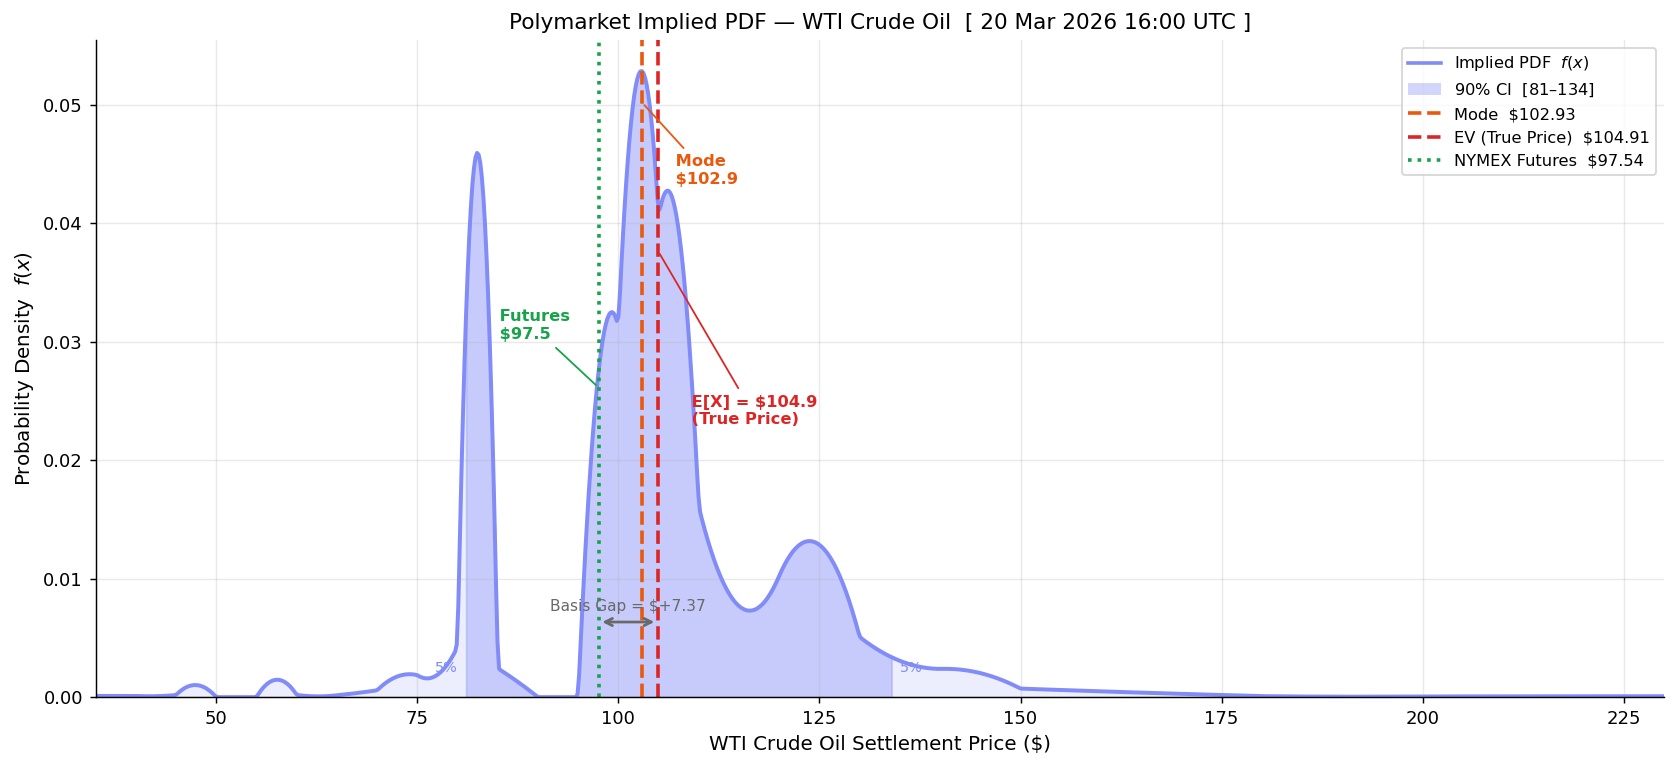

Saved → outputs/true_price_pdf.png


In [10]:

# ── Plot 2 · PDF — Most Likely vs Expected Price ──────────────────────────────
x, pdf_s = result["x_grid"], result["pdf"]
lo, hi   = result["ci_90"]
dx       = x[1] - x[0]

fig, ax = plt.subplots(figsize=(13, 6))

# ── Full PDF area fill ────────────────────────────────────────────────────────
ax.fill_between(x, pdf_s, alpha=0.15, color=P["pdf_fill"])
ax.plot(x, pdf_s, color=P["pdf_fill"], lw=2.2, label="Implied PDF  $f(x)$")

# ── 90% CI shaded darker ─────────────────────────────────────────────────────
ci_mask = (x >= lo) & (x <= hi)
ax.fill_between(x[ci_mask], pdf_s[ci_mask], alpha=0.35, color=P["pdf_fill"],
                label=f"90% Credible Interval  [${lo:.0f} – ${hi:.0f}]")

# ── Mode ──────────────────────────────────────────────────────────────────────
mode_y = float(pdf_s[np.argmax(pdf_s)])
ax.axvline(result["mode"], color=P["mode"], lw=2.0, ls="--")
ax.annotate(
    f" Mode\n ${result['mode']:.1f}",
    xy=(result["mode"], mode_y * 0.95),
    xytext=(result["mode"] + 3.5, mode_y * 0.82),
    fontsize=9, color=P["mode"], fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=P["mode"], lw=1.0),
)

# ── Expected Value ────────────────────────────────────────────────────────────
ev_y = float(np.interp(result["ev"], x, pdf_s))
ax.axvline(result["ev"], color=P["ev"], lw=2.0, ls="--")
ax.annotate(
    f" E[X] = ${result['ev']:.1f}\n (True Price)",
    xy=(result["ev"], ev_y * 0.90),
    xytext=(result["ev"] + 3.5, ev_y * 0.55),
    fontsize=9, color=P["ev"], fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=P["ev"], lw=1.0),
)

# ── NYMEX Futures ─────────────────────────────────────────────────────────────
fut_y = float(np.interp(futures, x, pdf_s))
ax.axvline(futures, color=P["futures"], lw=2.0, ls=":")
ax.annotate(
    f" Futures\n ${futures:.1f}",
    xy=(futures, fut_y * 0.95),
    xytext=(futures - 13, fut_y * 1.10),
    fontsize=9, color=P["futures"], fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=P["futures"], lw=1.0),
)

# ── Basis gap arrow ───────────────────────────────────────────────────────────
gap = result["ev"] - futures
mid_y = max(pdf_s) * 0.12
ax.annotate(
    "",
    xy=(result["ev"], mid_y), xytext=(futures, mid_y),
    arrowprops=dict(arrowstyle="<->", color="dimgray", lw=1.5),
)
ax.text((result["ev"] + futures) / 2, mid_y * 1.15,
        f"Basis Gap = ${gap:+.2f}",
        ha="center", fontsize=8.5, color="dimgray")

# ── Probability mass labels on tails ─────────────────────────────────────────
p_below = float(np.trapz(pdf_s[x < lo], x[x < lo]))
p_above = float(np.trapz(pdf_s[x > hi], x[x > hi]))
ax.text(lo - 1, max(pdf_s) * 0.04, f"5%", ha="right", fontsize=8, color=P["pdf_fill"])
ax.text(hi + 1, max(pdf_s) * 0.04, f"5%", ha="left",  fontsize=8, color=P["pdf_fill"])

# ── Legend & labels ───────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=P["pdf_fill"], lw=2, label="Implied PDF  $f(x)$"),
    Patch(facecolor=P["pdf_fill"], alpha=0.35, label=f"90% CI  [${lo:.0f}–${hi:.0f}]"),
    Line2D([0], [0], color=P["mode"],    lw=2, ls="--", label=f"Mode  ${result['mode']:.2f}"),
    Line2D([0], [0], color=P["ev"],      lw=2, ls="--", label=f"EV (True Price)  ${result['ev']:.2f}"),
    Line2D([0], [0], color=P["futures"], lw=2, ls=":",  label=f"NYMEX Futures  ${futures:.2f}"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")
ax.set_xlabel("WTI Crude Oil Settlement Price ($)", fontsize=11)
ax.set_ylabel("Probability Density  $f(x)$", fontsize=11)
ax.set_title(f"Polymarket Implied PDF — WTI Crude Oil  "
             f"[ {T_DEMO.strftime('%d %b %Y %H:%M')} UTC ]", fontsize=12)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(0)
plt.tight_layout()
plt.savefig("../outputs/true_price_pdf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/true_price_pdf.png")


---
## 4 · Rolling Alpha Signal

Compute the Polymarket Implied EV at every 2-hour interval over the full dataset and compare to the concurrent NYMEX futures price.

In [11]:

def compute_rolling_ev(pm_raw,
                       nymex_1h,
                       freq         = "2h",
                       min_strikes  = 6,
                       z_threshold  = 1.0):
    """
    Compute Polymarket Implied EV, Basis Gap, and Z-score signal at each
    sampled timestamp across the full dataset.

    Parameters
    ──────────
    freq        : Sampling frequency (default "2h" — 336 points over 28 days)
    min_strikes : Minimum number of CDF points required to compute EV
    z_threshold : Signal trigger threshold for Z-score

    Returns
    ───────
    DataFrame indexed by timestamp with columns:
      pm_ev, pm_mode, nymex, basis, z_score, signal, ci_lo, ci_hi
    """
    timestamps = pd.date_range(
        start = pm_raw["timestamp"].min().ceil(freq),
        end   = pm_raw["timestamp"].max().floor(freq),
        freq  = freq,
    )

    results, gap_history = [], []

    for t in timestamps:
        # Need NYMEX coverage  (NYMEX starts Mar 1)
        if t < nymex_1h.index.min():
            continue
        fx = float(nymex_1h.asof(t))
        if np.isnan(fx):
            continue

        snap = build_cdf_snapshot(pm_raw, t)
        if len(snap) < min_strikes:
            continue

        try:
            res = fit_smooth_cdf(snap)
        except Exception:
            continue

        sig = alpha_signal(res["ev"], fx, gap_history=gap_history,
                           z_threshold=z_threshold)
        gap_history.append(sig["basis_gap"])

        results.append({
            "timestamp": t,
            "pm_ev":     res["ev"],
            "pm_mode":   res["mode"],
            "nymex":     fx,
            "basis":     sig["basis_gap"],
            "z_score":   sig["z_score"],
            "signal":    sig["signal"],
            "ci_lo":     res["ci_90"][0],
            "ci_hi":     res["ci_90"][1],
            "n_strikes": len(snap),
        })

    df = pd.DataFrame(results).set_index("timestamp")
    return df

# ── Run ───────────────────────────────────────────────────────────────────────
print("Computing rolling EV (sample every 2 h) …")
df_roll = compute_rolling_ev(pm_raw, nymex_1h, freq="2h", z_threshold=1.0)
print(f"Done — {len(df_roll)} snapshots  "
      f"({df_roll.index.min().date()} → {df_roll.index.max().date()})\n")
print(df_roll[["pm_ev", "nymex", "basis", "z_score"]].describe().round(4).to_string())


Computing rolling EV (sample every 2 h) …
Done — 319 snapshots  (2026-03-02 → 2026-03-28)

          pm_ev     nymex     basis   z_score
count  319.0000  319.0000  319.0000  319.0000
mean    94.5736   91.4384    3.1353   -0.3413
std     13.8401    8.6137   14.9430    1.3598
min     78.1392   70.0000  -18.9557   -3.3485
25%     81.2667   88.4350  -12.9913   -1.4139
50%     92.8898   93.7000    5.1071   -0.1557
75%    103.0161   98.2300   14.0680    0.3153
max    140.4386  115.8800   40.5965    3.8627


### Plot 3 — Alpha Spread: Polymarket EV vs NYMEX Futures Over Time

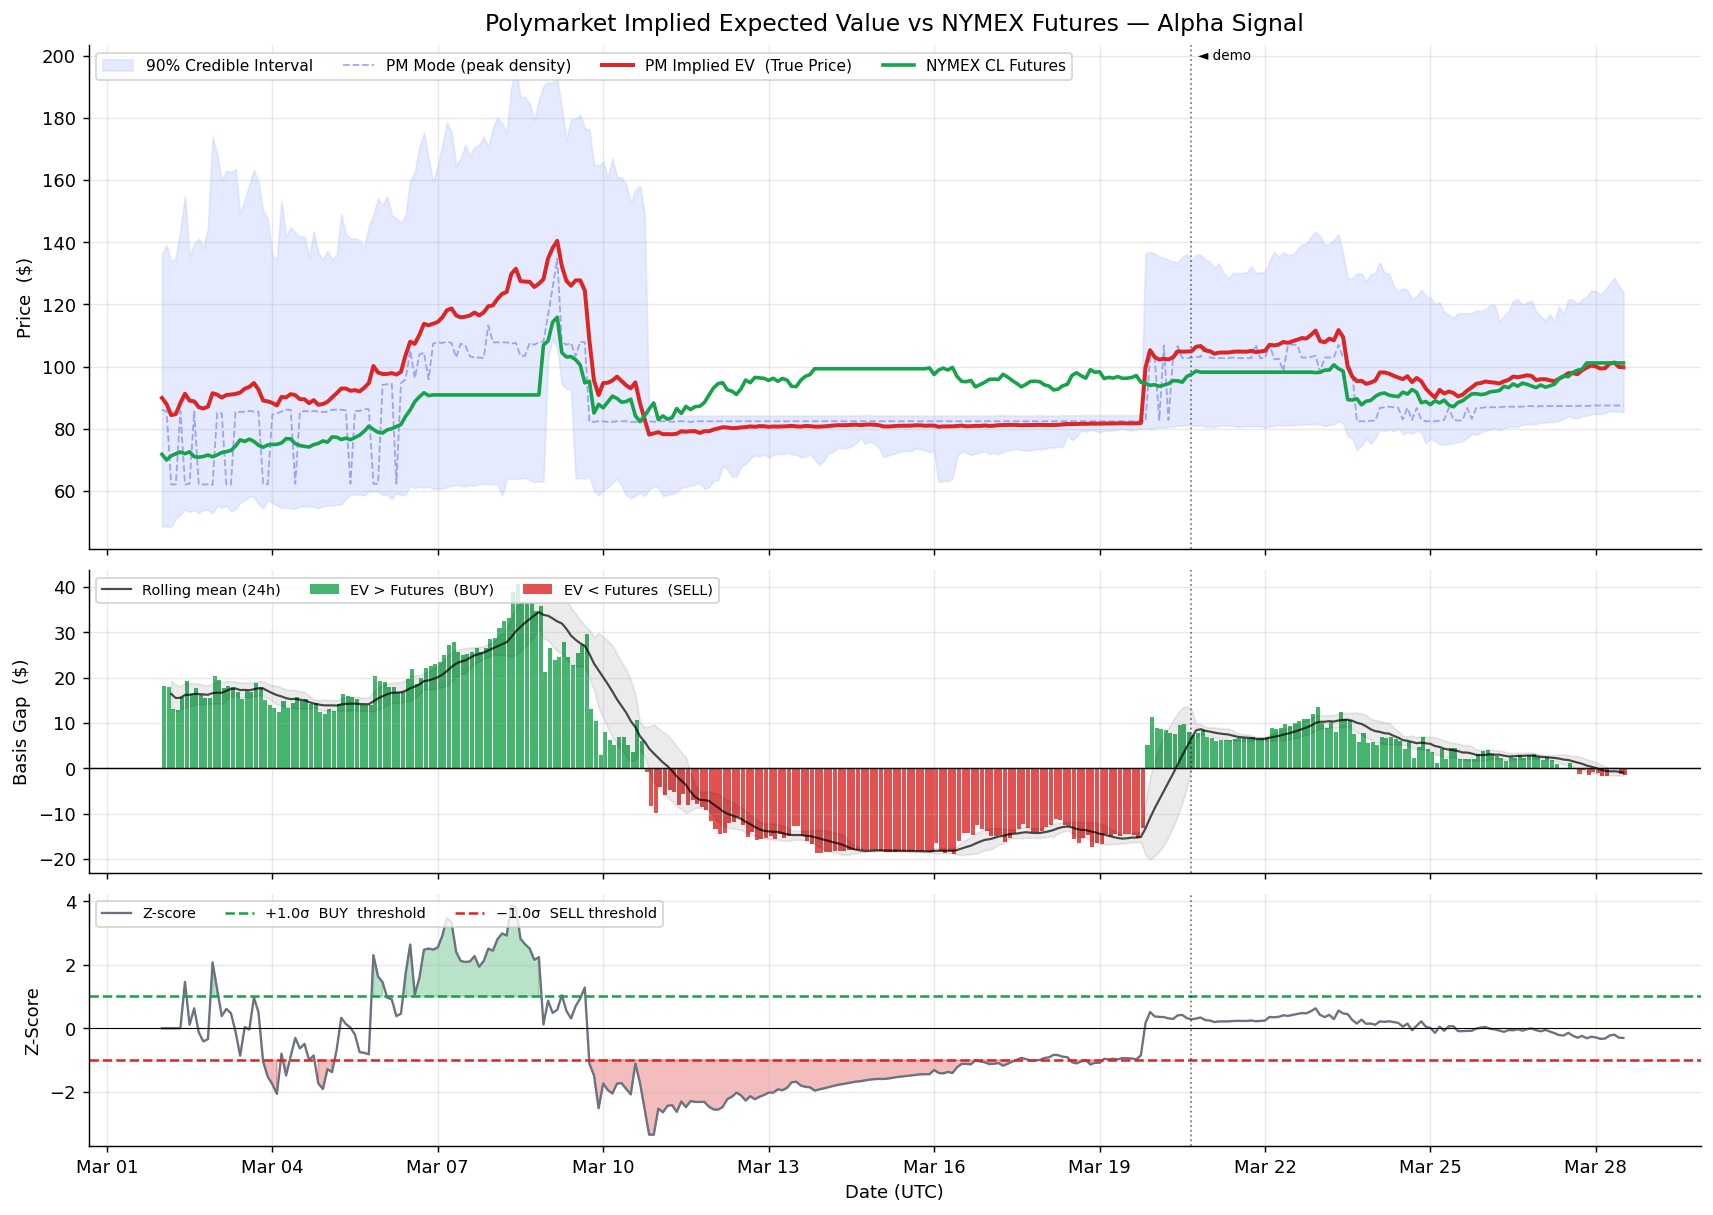

Saved → outputs/true_price_alpha_spread.png

  Signal distribution  (Z-threshold = 1.0σ):
  BUY  ▲    38 / 319  ( 11.9%)
  SELL ▼   110 / 319  ( 34.5%)
  HOLD ─   171 / 319  ( 53.6%)

  Basis Gap  mean=+3.135  std=14.943  max=+40.596  min=-18.956


In [12]:

# ── Plot 3 · Alpha Spread — Three-Panel Figure ────────────────────────────────
Z_THRESH = 1.0

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1.8, 1.5], hspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# ── Panel 1 · PM EV  vs  NYMEX Futures ───────────────────────────────────────
ax1.fill_between(df_roll.index, df_roll["ci_lo"], df_roll["ci_hi"],
                 color=P["ci"], alpha=0.45, zorder=0,
                 label="90% Credible Interval")
ax1.plot(df_roll.index, df_roll["pm_mode"],
         color=P["pdf_fill"], lw=1.0, ls="--", alpha=0.75,
         label="PM Mode (peak density)")
ax1.plot(df_roll.index, df_roll["pm_ev"],
         color=P["ev"], lw=2.2, zorder=3,
         label="PM Implied EV  (True Price)")
ax1.plot(df_roll.index, df_roll["nymex"],
         color=P["futures"], lw=2.0, zorder=3,
         label="NYMEX CL Futures")

# Mark demo snapshot
ax1.axvline(T_DEMO, color="k", lw=1, ls=":", alpha=0.5)
ax1.text(T_DEMO + pd.Timedelta("3h"), ax1.get_ylim()[1] * 0.995,
         "◄ demo", fontsize=7.5, va="top", color="k")

ax1.set_ylabel("Price  ($)", fontsize=10)
ax1.set_title("Polymarket Implied Expected Value vs NYMEX Futures — Alpha Signal",
              fontsize=13, pad=8)
ax1.legend(fontsize=8.5, ncol=4, loc="upper left",
           framealpha=0.9, edgecolor="lightgray")

# ── Panel 2 · Basis Gap ───────────────────────────────────────────────────────
pos_idx = df_roll["basis"] >= 0
neg_idx = df_roll["basis"] <  0
bar_w   = pd.Timedelta("105min")   # slightly under 2 h for visual separation

ax2.bar(df_roll.index[pos_idx], df_roll.loc[pos_idx, "basis"],
        width=bar_w, color=P["buy"],  alpha=0.80, align="edge",
        label="EV > Futures  (BUY)")
ax2.bar(df_roll.index[neg_idx], df_roll.loc[neg_idx, "basis"],
        width=bar_w, color=P["sell"], alpha=0.80, align="edge",
        label="EV < Futures  (SELL)")
ax2.axhline(0, color="k", lw=0.8)

# Rolling mean  ±1 std band
roll_mu  = df_roll["basis"].rolling(12, min_periods=3).mean()
roll_std = df_roll["basis"].rolling(12, min_periods=3).std(ddof=1)
ax2.plot(df_roll.index, roll_mu, color="k", lw=1.2, ls="-", alpha=0.7,
         label="Rolling mean (24h)")
ax2.fill_between(df_roll.index,
                 roll_mu - roll_std, roll_mu + roll_std,
                 color="k", alpha=0.08)

ax2.set_ylabel("Basis Gap  ($)", fontsize=10)
ax2.legend(fontsize=8, loc="upper left", ncol=3)
ax2.axvline(T_DEMO, color="k", lw=1, ls=":", alpha=0.5)

# ── Panel 3 · Z-score ─────────────────────────────────────────────────────────
ax3.plot(df_roll.index, df_roll["z_score"],
         color=P["zscore"], lw=1.3, zorder=2, label="Z-score")
ax3.axhline( Z_THRESH, color=P["buy"],  lw=1.4, ls="--",
             label=f"+{Z_THRESH}σ  BUY  threshold")
ax3.axhline(-Z_THRESH, color=P["sell"], lw=1.4, ls="--",
             label=f"−{Z_THRESH}σ  SELL threshold")
ax3.axhline(0, color="k", lw=0.6)

# Shade the triggered regions
ax3.fill_between(df_roll.index, df_roll["z_score"],  Z_THRESH,
                 where=df_roll["z_score"] >  Z_THRESH,
                 color=P["buy"],  alpha=0.30, label="_")
ax3.fill_between(df_roll.index, df_roll["z_score"], -Z_THRESH,
                 where=df_roll["z_score"] < -Z_THRESH,
                 color=P["sell"], alpha=0.30, label="_")

ax3.set_ylabel("Z-Score", fontsize=10)
ax3.set_xlabel("Date (UTC)", fontsize=10)
ax3.legend(fontsize=8, loc="upper left", ncol=3)
ax3.axvline(T_DEMO, color="k", lw=1, ls=":", alpha=0.5)

# ── Shared x-axis ticks ───────────────────────────────────────────────────────
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.savefig("../outputs/true_price_alpha_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/true_price_alpha_spread.png")

# ── Signal frequency ──────────────────────────────────────────────────────────
n_buy  = (df_roll["signal"] ==  1).sum()
n_sell = (df_roll["signal"] == -1).sum()
n_hold = (df_roll["signal"] ==  0).sum()
n_tot  = len(df_roll)
print(f"\n  Signal distribution  (Z-threshold = {Z_THRESH}σ):")
print(f"  BUY  ▲  {n_buy:>4} / {n_tot}  ({100*n_buy/n_tot:>5.1f}%)")
print(f"  SELL ▼  {n_sell:>4} / {n_tot}  ({100*n_sell/n_tot:>5.1f}%)")
print(f"  HOLD ─  {n_hold:>4} / {n_tot}  ({100*n_hold/n_tot:>5.1f}%)")
print(f"\n  Basis Gap  mean={df_roll['basis'].mean():+.3f}  "
      f"std={df_roll['basis'].std():.3f}  "
      f"max={df_roll['basis'].max():+.3f}  "
      f"min={df_roll['basis'].min():+.3f}")


---
## 5 · Summary

In [13]:

# ── Summary Table ─────────────────────────────────────────────────────────────
n_buy  = (df_roll["signal"] ==  1).sum()
n_sell = (df_roll["signal"] == -1).sum()

snap_summary = pd.DataFrame([
    {"Metric": "Method",
     "Value": "PCHIP + Log-Normal tails",
     "Note": "Smooth CDF → PDF → E[X]"},
    {"Metric": "Demo snapshot (Mar 20 16:00 UTC)",
     "Value": f"${result['ev']:.2f}",
     "Note": f"EV  |  NYMEX: ${futures:.2f}  |  Gap: ${result['ev']-futures:+.2f}"},
    {"Metric": "Log-Normal fit  (μ, σ)",
     "Value": f"({mu_ln:.4f},  {sig_ln:.4f})",
     "Note": f"scale = e^μ = ${np.exp(mu_ln):.2f}"},
    {"Metric": "90% Credible Interval",
     "Value": f"[${lo:.1f},  ${hi:.1f}]",
     "Note": "Width reflects crowd uncertainty"},
    {"Metric": "Rolling period",
     "Value": f"{df_roll.index.min().date()} → {df_roll.index.max().date()}",
     "Note": f"{len(df_roll)} snapshots at 2-hour frequency"},
    {"Metric": "Mean Basis Gap  (EV − Futures)",
     "Value": f"${df_roll['basis'].mean():+.3f}",
     "Note": "Positive = PM crowd prices higher on average"},
    {"Metric": "Basis Gap Std Dev",
     "Value": f"${df_roll['basis'].std():.3f}",
     "Note": "Spread of the alpha signal"},
    {"Metric": "BUY signals  (Z > +1σ)",
     "Value": f"{n_buy}  ({100*n_buy/len(df_roll):.1f}%)",
     "Note": "Polymarket EV > Futures  →  futures may rise"},
    {"Metric": "SELL signals  (Z < −1σ)",
     "Value": f"{n_sell}  ({100*n_sell/len(df_roll):.1f}%)",
     "Note": "Polymarket EV < Futures  →  futures may fall"},
])

print("=" * 75)
print(f"  TRUE PRICE ALPHA MODEL — WTI Crude Oil  (Polymarket × NYMEX CL)")
print("=" * 75)
print(snap_summary.to_string(index=False))
print("=" * 75)

try:
    display(snap_summary.style
            .set_caption("True Price Model — Summary")
            .set_table_styles([
                {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#EEF2FF")]},
                {"selector": "tr:nth-child(even)", "props": [("background-color", "#F8FAFF")]},
            ]))
except Exception:
    pass


  TRUE PRICE ALPHA MODEL — WTI Crude Oil  (Polymarket × NYMEX CL)
                          Metric                    Value                                         Note
                          Method PCHIP + Log-Normal tails                      Smooth CDF → PDF → E[X]
Demo snapshot (Mar 20 16:00 UTC)                  $104.91         EV  |  NYMEX: $97.54  |  Gap: $+7.37
          Log-Normal fit  (μ, σ)        (4.6498,  0.1664)                        scale = e^μ = $104.57
           90% Credible Interval         [$81.1,  $134.0]             Width reflects crowd uncertainty
                  Rolling period  2026-03-02 → 2026-03-28            319 snapshots at 2-hour frequency
  Mean Basis Gap  (EV − Futures)                  $+3.135 Positive = PM crowd prices higher on average
               Basis Gap Std Dev                  $14.943                   Spread of the alpha signal
          BUY signals  (Z > +1σ)              38  (11.9%) Polymarket EV > Futures  →  futures may rise
       

,Metric,Value,Note
0,Method,PCHIP + Log-Normal tails,Smooth CDF → PDF → E[X]
1,Demo snapshot (Mar 20 16:00 UTC),$104.91,EV | NYMEX: $97.54 | Gap: $+7.37
2,"Log-Normal fit (μ, σ)","(4.6498, 0.1664)",scale = e^μ = $104.57
3,90% Credible Interval,"[$81.1, $134.0]",Width reflects crowd uncertainty
4,Rolling period,2026-03-02 → 2026-03-28,319 snapshots at 2-hour frequency
5,Mean Basis Gap (EV − Futures),$+3.135,Positive = PM crowd prices higher on average
6,Basis Gap Std Dev,$14.943,Spread of the alpha signal
7,BUY signals (Z > +1σ),38 (11.9%),Polymarket EV > Futures → futures may rise
8,SELL signals (Z < −1σ),110 (34.5%),Polymarket EV < Futures → futures may fall


## Section 5 — Lead / Lag Analysis: Does PM Implied EV Lead NYMEX Futures?

Cross-correlate **first-differences** of PM Implied EV and NYMEX Futures at lags −24 h → +24 h.  
A **positive peak lag** means EV moves *before* futures (EV leads); a **negative peak** means futures leads.

Peak cross-correlation : +0.3864  at lag +2 h
95% significance band  : ±0.1099
Verdict                : PM Implied EV LEADS NYMEX Futures by ~2 h


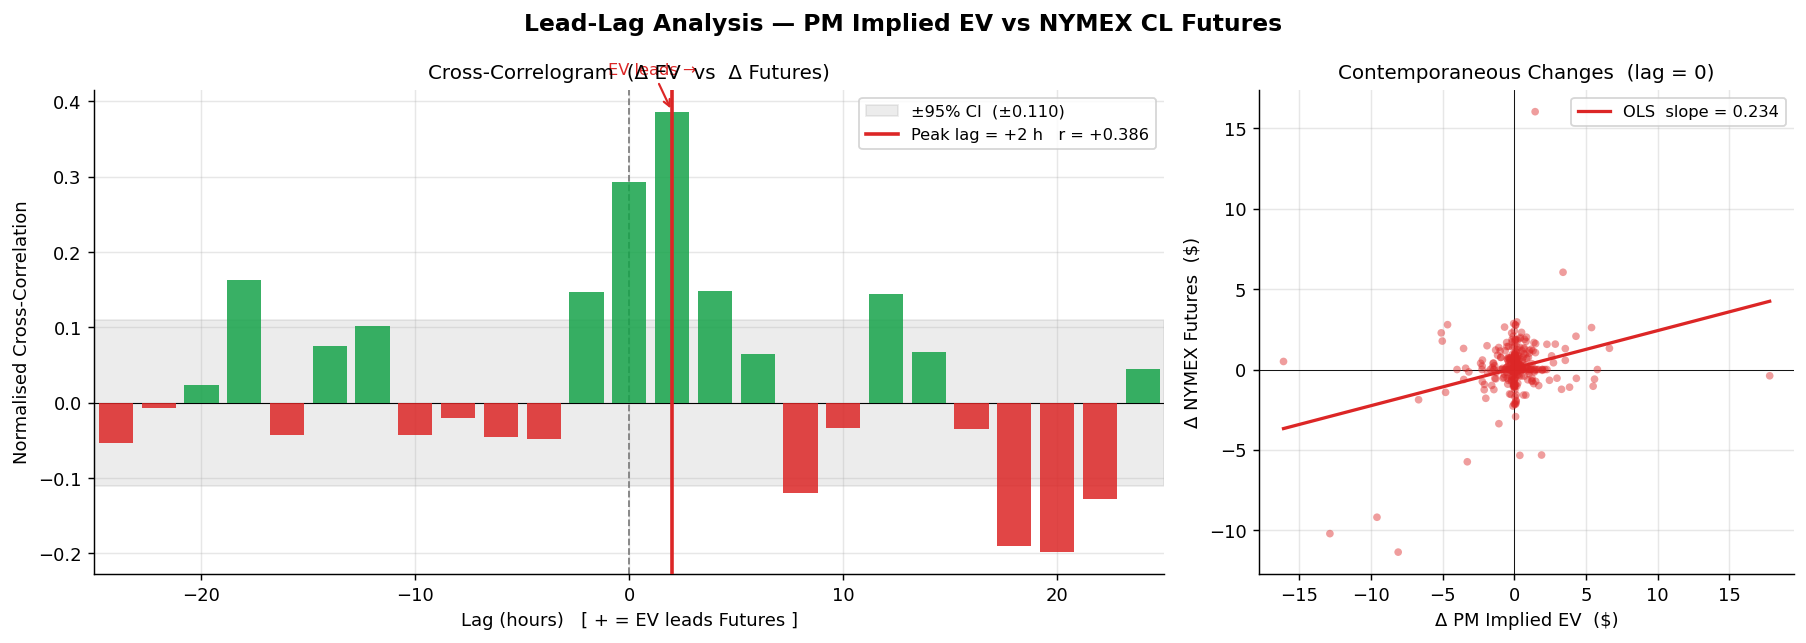

Saved → outputs/true_price_lead_lag.png


In [17]:
from scipy.signal import correlate, correlation_lags

# ── First-differences (stationarise both series) ──────────────────────────────
ev_diff  = df_roll["pm_ev"].diff().dropna()
fut_diff = df_roll["nymex"].diff().dropna()

idx_com = ev_diff.index.intersection(fut_diff.index)
x = ev_diff.reindex(idx_com).values
y = fut_diff.reindex(idx_com).values

# ── Normalised cross-correlation ──────────────────────────────────────────────
MAX_LAG   = 12                                       # ±12 steps = ±24 h @ 2-h sampling
xcorr_raw = correlate(x - x.mean(), y - y.mean(), mode="full")
lags_raw  = correlation_lags(len(x), len(y), mode="full")

mask     = np.abs(lags_raw) <= MAX_LAG
lags_h   = lags_raw[mask] * 2                       # steps → hours
xcorr_n  = xcorr_raw[mask] / (np.std(x) * np.std(y) * len(x))

# 95% significance band
ci95 = 1.96 / np.sqrt(len(x))

peak_idx  = int(np.argmax(np.abs(xcorr_n)))
peak_lag  = int(lags_h[peak_idx])
peak_corr = float(xcorr_n[peak_idx])

if peak_lag > 0:
    verdict = f"PM Implied EV LEADS NYMEX Futures by ~{peak_lag} h"
elif peak_lag < 0:
    verdict = f"NYMEX Futures LEADS PM Implied EV by ~{abs(peak_lag)} h"
else:
    verdict = "PM Implied EV and NYMEX Futures move CONTEMPORANEOUSLY"

print(f"Peak cross-correlation : {peak_corr:+.4f}  at lag {peak_lag:+d} h")
print(f"95% significance band  : ±{ci95:.4f}")
print(f"Verdict                : {verdict}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [2, 1]})
fig.suptitle("Lead-Lag Analysis — PM Implied EV vs NYMEX CL Futures",
             fontsize=13, fontweight="bold")

# Left panel: cross-correlogram
ax_xc = axes[0]
bar_cols = [P["buy"] if c > 0 else P["sell"] for c in xcorr_n]
ax_xc.bar(lags_h, xcorr_n, width=1.6, color=bar_cols, alpha=0.85, zorder=3)
ax_xc.axhspan(-ci95, ci95, color="grey", alpha=0.15,
              label=f"±95% CI  (±{ci95:.3f})")
ax_xc.axvline(0,          color="grey",   lw=1.0, ls="--", zorder=2)
ax_xc.axvline(peak_lag,   color=P["ev"], lw=2.0, ls="-", zorder=4,
              label=f"Peak lag = {peak_lag:+d} h   r = {peak_corr:+.3f}")
ax_xc.axhline(0, color="black", lw=0.6)
ax_xc.set_xlabel("Lag (hours)   [ + = EV leads Futures ]", fontsize=10)
ax_xc.set_ylabel("Normalised Cross-Correlation", fontsize=10)
ax_xc.set_title("Cross-Correlogram  (Δ EV  vs  Δ Futures)", fontsize=11)
ax_xc.legend(fontsize=9)
ax_xc.grid(True, alpha=0.3, zorder=1)
ax_xc.set_xlim(lags_h[0] - 1, lags_h[-1] + 1)
ax_xc.annotate(
    f"{'EV leads →' if peak_lag > 0 else '← Futures leads'}",
    xy=(peak_lag, peak_corr),
    xytext=(peak_lag + (3 if peak_lag <= 0 else -3), peak_corr + 0.05),
    fontsize=9, color=P["ev"],
    arrowprops=dict(arrowstyle="->", color=P["ev"], lw=1.2),
)

# Right panel: scatter of contemporaneous changes
ax_sc = axes[1]
ax_sc.scatter(x, y, s=18, alpha=0.45, color=P["ev"],
              edgecolors="none", zorder=3)
m, b = np.polyfit(x, y, 1)
xr = np.linspace(x.min(), x.max(), 200)
ax_sc.plot(xr, m * xr + b, color=P["sell"], lw=1.8,
           label=f"OLS  slope = {m:.3f}")
ax_sc.axhline(0, color="black", lw=0.5)
ax_sc.axvline(0, color="black", lw=0.5)
ax_sc.set_xlabel("Δ PM Implied EV  ($)", fontsize=10)
ax_sc.set_ylabel("Δ NYMEX Futures  ($)", fontsize=10)
ax_sc.set_title("Contemporaneous Changes  (lag = 0)", fontsize=11)
ax_sc.legend(fontsize=9)
ax_sc.grid(True, alpha=0.3, zorder=1)

plt.tight_layout()
out_path = ROOT / "outputs" / "true_price_lead_lag.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path.relative_to(ROOT)}")
